# Results Analysis

Analyze backtest results, experiment results, and the learned Q-table.  
All figures are saved to `notebook/outputs/`.

## 1. Setup

Load libraries, find the project root, and define file paths.

In [94]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook is expected to run from root/notebook/
PROJECT_ROOT = Path("..").resolve()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "notebook" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BACKTEST_PATH = PROCESSED_DIR / "backtest_results.csv"
EXPERIMENT_PATH = PROCESSED_DIR / "experiment_results.csv"
QTABLE_PATH = PROJECT_ROOT / "rl" / "qtable.json"

## 2. Load Data

Read the backtest results, experiment results, and Q-table.

In [95]:
backtest_df = pd.read_csv(BACKTEST_PATH)
experiment_df = pd.read_csv(EXPERIMENT_PATH)

with open(QTABLE_PATH, "r") as f:
    qtable = json.load(f)

display(backtest_df)
display(experiment_df)
print(f"Number of Q-table states: {len(qtable):,}")

,strategy,total_return,sharpe,max_drawdown
0,Q-Learning,0.486195,1.749025,-0.140154
1,Buy-and-Hold,0.342455,1.452713,-0.141370
2,Random,0.312105,1.364972,-0.148314


,config,use_confidence,use_vol,ql_return_pct,ql_final_value,ql_sharpe,ql_max_dd_pct,bh_return_pct
0,baseline,False,False,40.5,14051.0,1.38,-13.4,34.2
1,conf_only,True,False,62.0,16197.0,1.95,-13.0,34.2
2,vol_only,False,True,69.5,16952.0,1.88,-19.6,34.2
3,both,True,True,62.9,16295.0,1.98,-11.2,34.2


Number of Q-table states: 1,205


## 3. Helper Functions

Utility functions for saving figures and parsing Q-table states.

In [96]:
ACTION_NAMES = {0: "SELL", 1: "HOLD", 2: "BUY"}

def save_fig(filename: str):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    return path

def add_bar_labels(ax, fmt="{:.1f}", suffix=""):
    ymin, ymax = ax.get_ylim()
    offset = (ymax - ymin) * 0.01
    for bar in ax.patches:
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        y = height + offset if height >= 0 else height - offset
        va = "bottom" if height >= 0 else "top"
        ax.text(x, y, fmt.format(height) + suffix, ha="center", va=va, fontsize=9)

def parse_state(state: str) -> dict:
    result = {}
    for part in state.split("|"):
        if "=" in part:
            k, v = part.split("=", 1)
            result[k] = v
    return result

def qtable_to_policy_df(qtable: dict) -> pd.DataFrame:
    rows = []
    for state, q_values in qtable.items():
        q_values = np.array(q_values, dtype=float)
        best_action_id = int(np.argmax(q_values))
        sorted_q = np.sort(q_values)

        row = {
            "state": state,
            "q_sell": q_values[0],
            "q_hold": q_values[1],
            "q_buy": q_values[2],
            "best_action": ACTION_NAMES[best_action_id],
            "q_margin": float(sorted_q[-1] - sorted_q[-2]),
        }
        row.update(parse_state(state))
        rows.append(row)

    df = pd.DataFrame(rows)
    if "lots" in df.columns:
        df["lots"] = pd.to_numeric(df["lots"], errors="coerce")
    return df

policy_df = qtable_to_policy_df(qtable)
display(policy_df.head())

,state,q_sell,q_hold,q_buy,best_action,q_margin,trend,volume,volatility,recent_return,sec_ai,lots
0,trend=low|volume=nan|volatility=nan|recent_ret...,0.077589,0.077619,0.077489,HOLD,0.000030,low,nan,nan,medium,low,0
1,trend=low|volume=nan|volatility=nan|recent_ret...,0.080796,0.080279,0.082195,BUY,0.001398,low,nan,nan,low,low,0
2,trend=low|volume=nan|volatility=nan|recent_ret...,0.083868,0.085873,0.086483,BUY,0.000610,low,nan,nan,high,low,1
3,trend=low|volume=nan|volatility=nan|recent_ret...,0.079991,0.080430,0.080162,HOLD,0.000268,low,nan,nan,high,low,0
4,trend=low|volume=nan|volatility=nan|recent_ret...,0.077687,0.085362,0.085998,BUY,0.000636,low,nan,nan,medium,low,1


## 4. Backtest Results

Compare Q-learning with Buy-and-Hold and Random baselines.

In [97]:
bt = backtest_df.copy()
bt["return_pct"] = bt["total_return"] * 100
bt["max_drawdown_pct"] = bt["max_drawdown"] * 100
bt["final_value"] = 10_000 * (1 + bt["total_return"])

display(bt[["strategy", "return_pct", "final_value", "sharpe", "max_drawdown_pct"]])

,strategy,return_pct,final_value,sharpe,max_drawdown_pct
0,Q-Learning,48.619483,14861.948299,1.749025,-14.015391
1,Buy-and-Hold,34.245499,13424.549866,1.452713,-14.137010
2,Random,31.210520,13121.051979,1.364972,-14.831443


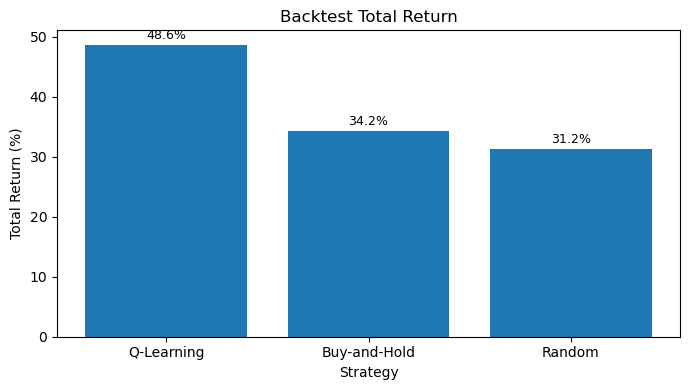

In [98]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bt["strategy"], bt["return_pct"])
ax.set_title("Backtest Total Return")
ax.set_ylabel("Total Return (%)")
ax.set_xlabel("Strategy")
add_bar_labels(ax, suffix="%")
save_fig("01_backtest_total_return.png")
plt.show()

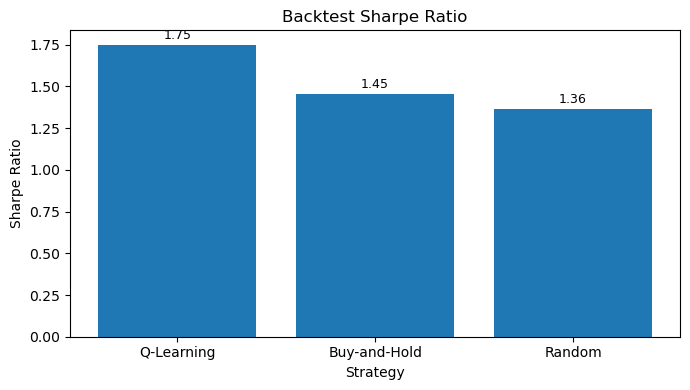

In [99]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bt["strategy"], bt["sharpe"])
ax.set_title("Backtest Sharpe Ratio")
ax.set_ylabel("Sharpe Ratio")
ax.set_xlabel("Strategy")
add_bar_labels(ax, fmt="{:.2f}")
save_fig("02_backtest_sharpe.png")
plt.show()

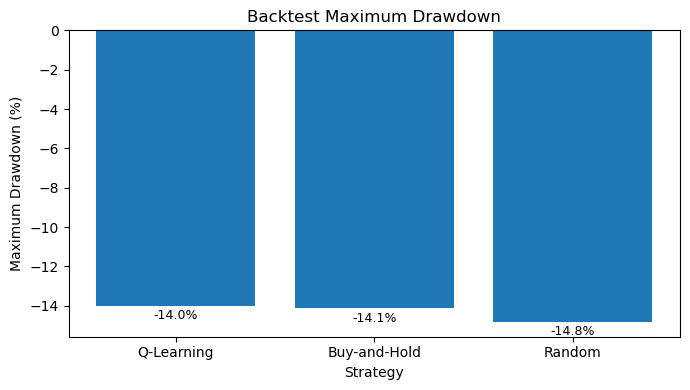

In [100]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bt["strategy"], bt["max_drawdown_pct"])
ax.set_title("Backtest Maximum Drawdown")
ax.set_ylabel("Maximum Drawdown (%)")
ax.set_xlabel("Strategy")
add_bar_labels(ax, suffix="%")
save_fig("03_backtest_max_drawdown.png")
plt.show()

### Backtest Summary

The cell below generates a short summary for the report.

In [101]:
ql = bt[bt["strategy"].str.lower().str.contains("q")].iloc[0]
bh = bt[bt["strategy"].str.lower().str.contains("buy")].iloc[0]
rnd = bt[bt["strategy"].str.lower().str.contains("random")].iloc[0]

summary = (
    f"Q-learning achieved a {ql['return_pct']:.1f}% return, compared with "
    f"{bh['return_pct']:.1f}% for Buy-and-Hold and {rnd['return_pct']:.1f}% for Random. "
    f"It also achieved the highest Sharpe ratio ({ql['sharpe']:.2f}) with a maximum "
    f"drawdown of {ql['max_drawdown_pct']:.1f}%."
)

print(summary)

Q-learning achieved a 48.6% return, compared with 34.2% for Buy-and-Hold and 31.2% for Random. It also achieved the highest Sharpe ratio (1.75) with a maximum drawdown of -14.0%.


## 5. Experiment Results

Compare fixed lot sizing with confidence-based and volatility-based dynamic lot sizing.

In [102]:
exp = experiment_df.copy()

if "vs_bh_pct" not in exp.columns and "bh_return_pct" in exp.columns:
    exp["vs_bh_pct"] = exp["ql_return_pct"] - exp["bh_return_pct"]

display(exp)

,config,use_confidence,use_vol,ql_return_pct,ql_final_value,ql_sharpe,ql_max_dd_pct,bh_return_pct,vs_bh_pct
0,baseline,False,False,40.5,14051.0,1.38,-13.4,34.2,6.3
1,conf_only,True,False,62.0,16197.0,1.95,-13.0,34.2,27.8
2,vol_only,False,True,69.5,16952.0,1.88,-19.6,34.2,35.3
3,both,True,True,62.9,16295.0,1.98,-11.2,34.2,28.7


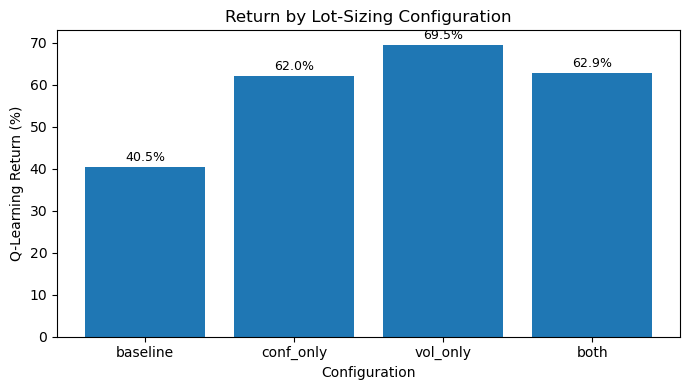

In [103]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(exp["config"], exp["ql_return_pct"])
ax.set_title("Return by Lot-Sizing Configuration")
ax.set_ylabel("Q-Learning Return (%)")
ax.set_xlabel("Configuration")
add_bar_labels(ax, suffix="%")
save_fig("04_experiment_return_by_config.png")
plt.show()

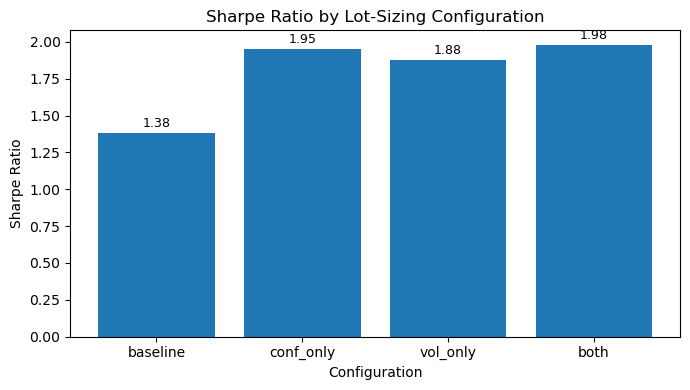

In [104]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(exp["config"], exp["ql_sharpe"])
ax.set_title("Sharpe Ratio by Lot-Sizing Configuration")
ax.set_ylabel("Sharpe Ratio")
ax.set_xlabel("Configuration")
add_bar_labels(ax, fmt="{:.2f}")
save_fig("05_experiment_sharpe_by_config.png")
plt.show()

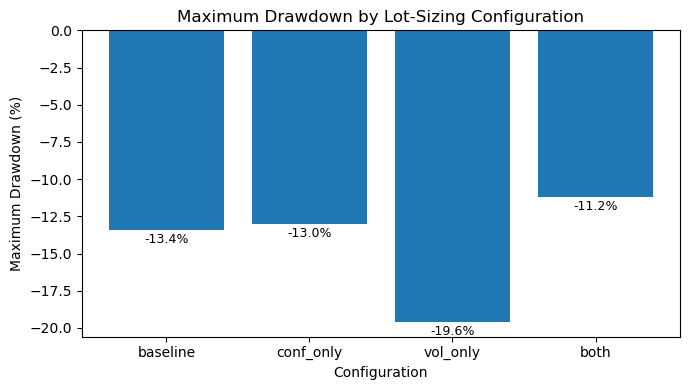

In [105]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(exp["config"], exp["ql_max_dd_pct"])
ax.set_title("Maximum Drawdown by Lot-Sizing Configuration")
ax.set_ylabel("Maximum Drawdown (%)")
ax.set_xlabel("Configuration")
add_bar_labels(ax, suffix="%")
save_fig("06_experiment_drawdown_by_config.png")
plt.show()

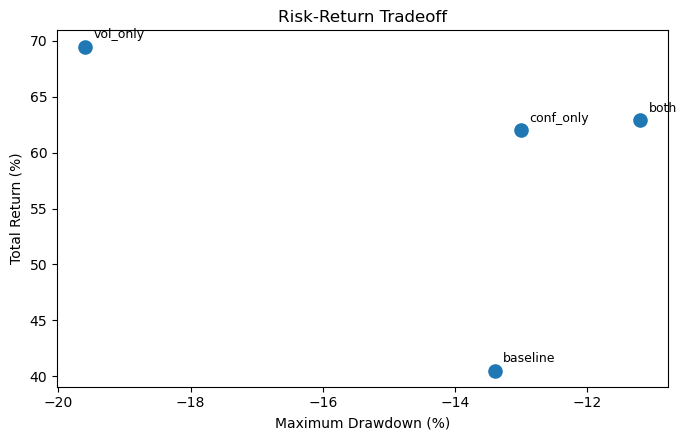

In [106]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(exp["ql_max_dd_pct"], exp["ql_return_pct"], s=90)

for _, row in exp.iterrows():
    ax.annotate(
        row["config"],
        (row["ql_max_dd_pct"], row["ql_return_pct"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )

ax.set_title("Risk-Return Tradeoff")
ax.set_xlabel("Maximum Drawdown (%)")
ax.set_ylabel("Total Return (%)")
save_fig("07_experiment_risk_return_tradeoff.png")
plt.show()

### Experiment Summary

The cell below generates a short summary for the report.

In [107]:
baseline = exp[exp["config"] == "baseline"].iloc[0]
best_return = exp.loc[exp["ql_return_pct"].idxmax()]
best_sharpe = exp.loc[exp["ql_sharpe"].idxmax()]
best_drawdown = exp.loc[exp["ql_max_dd_pct"].idxmax()]  # less negative is better

summary = (
    f"The baseline Q-learning model achieved a {baseline['ql_return_pct']:.1f}% return. "
    f"The highest raw return came from {best_return['config']} ({best_return['ql_return_pct']:.1f}%). "
    f"The best Sharpe ratio came from {best_sharpe['config']} ({best_sharpe['ql_sharpe']:.2f}). "
    f"The lowest drawdown came from {best_drawdown['config']} ({best_drawdown['ql_max_dd_pct']:.1f}%)."
)

print(summary)

The baseline Q-learning model achieved a 40.5% return. The highest raw return came from vol_only (69.5%). The best Sharpe ratio came from both (1.98). The lowest drawdown came from both (-11.2%).


## 6. Q-Table Policy Analysis

Inspect the greedy action learned for each state.

In [108]:
action_counts = (
    policy_df["best_action"]
    .value_counts()
    .rename_axis("best_action")
    .reset_index(name="state_count")
)
action_counts["state_pct"] = action_counts["state_count"] / len(policy_df) * 100

display(action_counts)

,best_action,state_count,state_pct
0,SELL,433,35.93361
1,BUY,425,35.26971
2,HOLD,347,28.79668


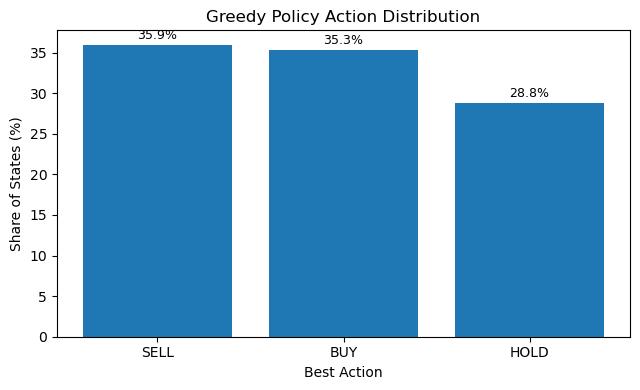

In [109]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(action_counts["best_action"], action_counts["state_pct"])
ax.set_title("Greedy Policy Action Distribution")
ax.set_ylabel("Share of States (%)")
ax.set_xlabel("Best Action")
add_bar_labels(ax, suffix="%")
save_fig("08_qtable_action_distribution.png")
plt.show()

In [110]:
policy_by_lots = (
    policy_df
    .dropna(subset=["lots"])
    .groupby(["lots", "best_action"])
    .size()
    .reset_index(name="count")
)

policy_by_lots["pct"] = (
    policy_by_lots["count"]
    / policy_by_lots.groupby("lots")["count"].transform("sum")
    * 100
)

policy_by_lots_pivot = (
    policy_by_lots
    .pivot(index="lots", columns="best_action", values="pct")
    .fillna(0)
    .reindex(columns=["SELL", "HOLD", "BUY"])
)

display(policy_by_lots_pivot)
policy_by_lots_pivot.to_csv(OUTPUT_DIR / "qtable_policy_by_lots.csv")

best_action,SELL,HOLD,BUY
lots,,,
0,32.921811,22.633745,44.444444
1,15.226337,43.209877,41.563786
2,36.625514,23.868313,39.506173
3,44.166667,29.583333,26.250000
4,51.271186,24.576271,24.152542


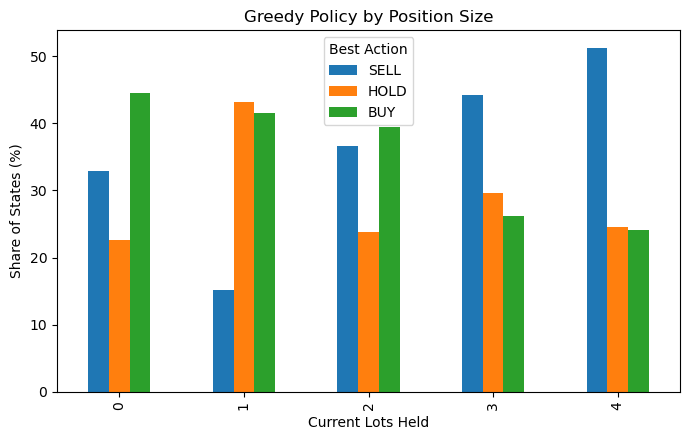

In [111]:
fig, ax = plt.subplots(figsize=(7, 4.5))
policy_by_lots_pivot.plot(kind="bar", ax=ax)
ax.set_title("Greedy Policy by Position Size")
ax.set_ylabel("Share of States (%)")
ax.set_xlabel("Current Lots Held")
ax.legend(title="Best Action")
save_fig("09_qtable_policy_by_lots.png")
plt.show()

best_action,SELL,HOLD,BUY
volatility,,,
low,32.911392,29.367089,37.721519
medium,36.250000,28.000000,35.750000
high,39.740260,28.311688,31.948052


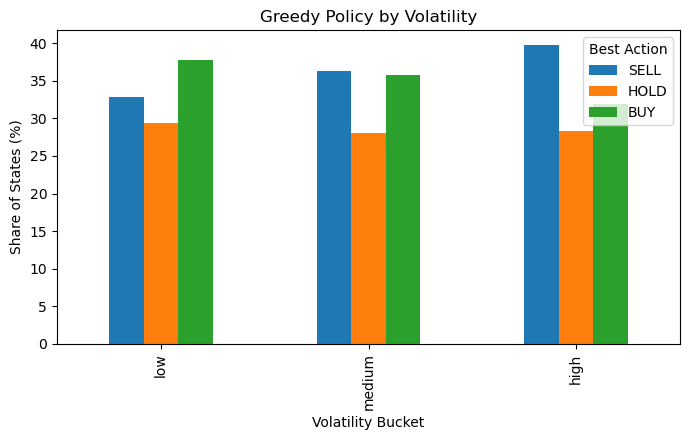

In [112]:
if "volatility" in policy_df.columns:
    policy_by_vol = (
        policy_df
        .groupby(["volatility", "best_action"])
        .size()
        .reset_index(name="count")
    )

    policy_by_vol["pct"] = (
        policy_by_vol["count"]
        / policy_by_vol.groupby("volatility")["count"].transform("sum")
        * 100
    )

    policy_by_vol_pivot = (
        policy_by_vol
        .pivot(index="volatility", columns="best_action", values="pct")
        .fillna(0)
        .reindex(index=["low", "medium", "high"])
        .reindex(columns=["SELL", "HOLD", "BUY"])
    )

    display(policy_by_vol_pivot)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    policy_by_vol_pivot.plot(kind="bar", ax=ax)
    ax.set_title("Greedy Policy by Volatility")
    ax.set_ylabel("Share of States (%)")
    ax.set_xlabel("Volatility Bucket")
    ax.legend(title="Best Action")
    save_fig("10_qtable_policy_by_volatility.png")
    plt.show()

## 7. Q-Value Margin

The Q-value margin measures how much better the best action is than the second-best action.

count    1205.000000
mean        0.009215
std         0.016512
min         0.000002
25%         0.001218
50%         0.003398
75%         0.008293
max         0.110506
Name: q_margin, dtype: float64

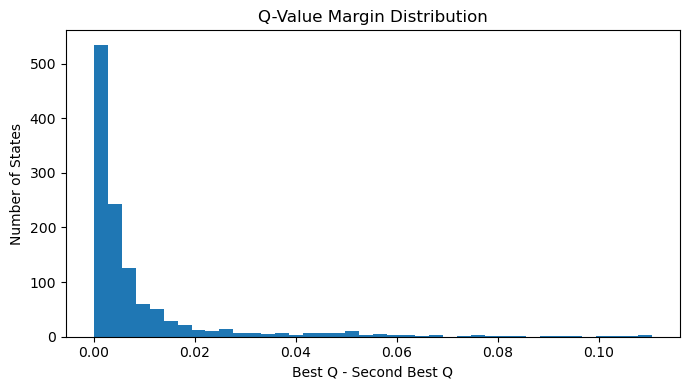

In [113]:
display(policy_df["q_margin"].describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(policy_df["q_margin"], bins=40)
ax.set_title("Q-Value Margin Distribution")
ax.set_xlabel("Best Q - Second Best Q")
ax.set_ylabel("Number of States")
save_fig("11_qtable_q_margin_distribution.png")
plt.show()

In [114]:
policy_df.to_csv(OUTPUT_DIR / "qtable_policy_analysis.csv", index=False)
print("Saved policy analysis CSV.")

Saved policy analysis CSV.


## 8. Recommended Figures

Use these figures in the project summary:

- `07_experiment_risk_return_tradeoff.png`
- `09_qtable_policy_by_lots.png`
- `04_experiment_return_by_config.png`
- `05_experiment_sharpe_by_config.png`

In [115]:
for path in sorted(OUTPUT_DIR.glob("*.png")):
    print(path.name)

01_backtest_total_return.png
02_backtest_sharpe.png
03_backtest_max_drawdown.png
04_experiment_return_by_config.png
05_experiment_sharpe_by_config.png
06_experiment_drawdown_by_config.png
07_experiment_risk_return_tradeoff.png
08_qtable_action_distribution.png
09_qtable_policy_by_lots.png
10_qtable_policy_by_volatility.png
11_qtable_q_margin_distribution.png


## 9. Short Captions

Use or edit these captions for the project summary.

In [116]:
captions = {
    "07_experiment_risk_return_tradeoff.png":
        "Risk-return tradeoff across Q-learning configurations.",
    "09_qtable_policy_by_lots.png":
        "The learned policy buys more often with no position and sells more often near the maximum position.",
    "04_experiment_return_by_config.png":
        "Dynamic lot sizing improves Q-learning returns over the fixed-lot baseline.",
    "05_experiment_sharpe_by_config.png":
        "The combined configuration achieves the best risk-adjusted performance.",
}

for name, caption in captions.items():
    print(f"{name}: {caption}")

07_experiment_risk_return_tradeoff.png: Risk-return tradeoff across Q-learning configurations.
09_qtable_policy_by_lots.png: The learned policy buys more often with no position and sells more often near the maximum position.
04_experiment_return_by_config.png: Dynamic lot sizing improves Q-learning returns over the fixed-lot baseline.
05_experiment_sharpe_by_config.png: The combined configuration achieves the best risk-adjusted performance.
